In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('bdt_mba_supplychain_dataset_2024.csv')
df.head()

,Asset_ID,Location,Temperature,Vibration,Last_Maintenance,Condition_Score,Resource_Utilization,Delivery_Efficiency,Downtime_Hours,Inventory_Level,Logistics_Cost,Timestamp,SupplyChain_Efficiency_Label
0,A0001,Lake Davidland,32.34,3.99,2023-09-28,67.39,87.04,79.99,3.22,Medium,5148.45,2024-09-13 19:31:26,0
1,A0002,West Andrew,25.99,0.80,2023-04-26,76.44,81.06,92.07,2.89,Low,4454.82,2023-09-17 22:20:17,1
2,A0003,New Kimberlyhaven,31.45,4.75,2024-12-23,61.85,79.64,88.15,1.65,High,3977.16,2024-09-08 19:32:27,1
3,A0004,Lake Cathyside,26.55,4.37,2024-10-22,63.60,79.88,72.63,8.07,Low,3248.65,2023-10-28 06:48:55,0
4,A0005,South Justin,41.66,1.43,2024-08-17,61.62,65.99,74.93,1.83,High,3121.08,2023-10-06 05:02:02,0


In [29]:
df.sample(10)

,Asset_ID,Location,Temperature,Vibration,Last_Maintenance,Condition_Score,Resource_Utilization,Delivery_Efficiency,Downtime_Hours,Inventory_Level,Logistics_Cost,Timestamp,SupplyChain_Efficiency_Label
155,A0156,Lake Manuelfurt,38.36,1.85,2024-03-06,64.73,63.53,87.16,9.77,Medium,6293.52,2024-09-21 21:59:36,0
393,A0394,Patriciafort,46.44,4.16,2023-05-05,88.95,91.26,75.90,8.83,High,4703.22,2024-11-04 12:19:02,0
181,A0182,New Darlene,28.55,1.67,2023-05-14,95.58,78.50,85.83,5.89,High,4481.66,2023-12-28 05:53:29,1
14,A0015,Smithtown,29.89,4.95,2023-01-14,69.33,82.17,77.96,6.03,High,4944.70,2023-05-03 08:17:21,0
7,A0008,New Dianaport,40.61,4.69,2023-01-26,70.51,62.85,95.43,3.04,High,4337.55,2023-01-23 05:43:53,0
318,A0319,Alexisstad,21.46,0.72,2023-02-22,70.84,61.04,89.21,8.35,Low,6032.26,2023-05-17 22:21:10,0
162,A0163,East Claire,48.93,4.40,2024-01-31,69.67,76.19,97.65,0.19,Low,4800.21,2024-10-01 17:48:12,1
415,A0416,Port Jesse,42.27,0.84,2024-07-13,68.97,78.98,95.47,8.33,Medium,5748.01,2024-06-20 23:33:09,1
311,A0312,Reevesshire,39.56,2.20,2023-09-17,66.37,85.98,70.02,4.95,Medium,3822.78,2024-03-15 06:20:17,0
434,A0435,Port Jerryland,31.17,0.51,2023-01-13,69.04,60.83,81.03,6.70,High,5648.01,2024-04-15 22:31:28,0


In [30]:
df.shape

(500, 13)

In [31]:
df.columns

Index(['Asset_ID', 'Location', 'Temperature', 'Vibration', 'Last_Maintenance',
       'Condition_Score', 'Resource_Utilization', 'Delivery_Efficiency',
       'Downtime_Hours', 'Inventory_Level', 'Logistics_Cost', 'Timestamp',
       'SupplyChain_Efficiency_Label'],
      dtype='str')

In [32]:
df.dtypes

Asset_ID                            str
Location                            str
Temperature                     float64
Vibration                       float64
Last_Maintenance                    str
Condition_Score                 float64
Resource_Utilization            float64
Delivery_Efficiency             float64
Downtime_Hours                  float64
Inventory_Level                     str
Logistics_Cost                  float64
Timestamp                           str
SupplyChain_Efficiency_Label      int64
dtype: object

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Asset_ID                      500 non-null    str    
 1   Location                      500 non-null    str    
 2   Temperature                   500 non-null    float64
 3   Vibration                     500 non-null    float64
 4   Last_Maintenance              500 non-null    str    
 5   Condition_Score               500 non-null    float64
 6   Resource_Utilization          500 non-null    float64
 7   Delivery_Efficiency           500 non-null    float64
 8   Downtime_Hours                500 non-null    float64
 9   Inventory_Level               500 non-null    str    
 10  Logistics_Cost                500 non-null    float64
 11  Timestamp                     500 non-null    str    
 12  SupplyChain_Efficiency_Label  500 non-null    int64  
dtypes: float64(7), i

In [34]:
df.describe()

,Temperature,Vibration,Condition_Score,Resource_Utilization,Delivery_Efficiency,Downtime_Hours,Logistics_Cost,SupplyChain_Efficiency_Label
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,34.691180,2.508240,74.878440,77.879940,84.165620,5.025020,4973.418100,0.506000
std,8.791835,1.470361,14.134638,10.075504,8.077746,2.961775,1183.049596,0.542727
min,20.080000,0.000000,50.010000,60.010000,70.020000,0.020000,3000.760000,0.000000
25%,26.687500,1.187500,62.687500,69.300000,77.080000,2.540000,4048.407500,0.000000
50%,34.575000,2.480000,74.780000,78.555000,84.595000,5.050000,4777.445000,0.000000
75%,42.275000,3.790000,87.357500,86.315000,90.665000,7.682500,6075.320000,1.000000
max,49.880000,4.990000,99.970000,94.960000,97.980000,10.000000,6999.180000,2.000000


In [35]:
df.isnull()

,Asset_ID,Location,Temperature,Vibration,Last_Maintenance,Condition_Score,Resource_Utilization,Delivery_Efficiency,Downtime_Hours,Inventory_Level,Logistics_Cost,Timestamp,SupplyChain_Efficiency_Label
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False,False,False,False,False


In [36]:
df.isnull().sum()

Asset_ID                        0
Location                        0
Temperature                     0
Vibration                       0
Last_Maintenance                0
Condition_Score                 0
Resource_Utilization            0
Delivery_Efficiency             0
Downtime_Hours                  0
Inventory_Level                 0
Logistics_Cost                  0
Timestamp                       0
SupplyChain_Efficiency_Label    0
dtype: int64

In [37]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df['Location'].duplicated().sum()

np.int64(12)

In [40]:
df.nunique()

Asset_ID                        500
Location                        488
Temperature                     457
Vibration                       318
Last_Maintenance                369
Condition_Score                 470
Resource_Utilization            464
Delivery_Efficiency             460
Downtime_Hours                  381
Inventory_Level                   3
Logistics_Cost                  500
Timestamp                       500
SupplyChain_Efficiency_Label      3
dtype: int64

In [41]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

Asset_ID : 500
Location : 488
Temperature : 457
Vibration : 318
Last_Maintenance : 369
Condition_Score : 470
Resource_Utilization : 464
Delivery_Efficiency : 460
Downtime_Hours : 381
Inventory_Level : 3
Logistics_Cost : 500
Timestamp : 500
SupplyChain_Efficiency_Label : 3


In [42]:
# mapping = {'Low': 0, 'Medium': 1, 'High': 2}
# df['Inventory_Level'] = df['Inventory_Level'].map(mapping)

In [43]:
numeric_df = df.select_dtypes('number')
numeric_df.head()

,Temperature,Vibration,Condition_Score,Resource_Utilization,Delivery_Efficiency,Downtime_Hours,Logistics_Cost,SupplyChain_Efficiency_Label
0,32.34,3.99,67.39,87.04,79.99,3.22,5148.45,0
1,25.99,0.80,76.44,81.06,92.07,2.89,4454.82,1
2,31.45,4.75,61.85,79.64,88.15,1.65,3977.16,1
3,26.55,4.37,63.60,79.88,72.63,8.07,3248.65,0
4,41.66,1.43,61.62,65.99,74.93,1.83,3121.08,0


In [44]:
category_df = df.select_dtypes('str')
category_df.head()

,Asset_ID,Location,Last_Maintenance,Inventory_Level,Timestamp
0,A0001,Lake Davidland,2023-09-28,Medium,2024-09-13 19:31:26
1,A0002,West Andrew,2023-04-26,Low,2023-09-17 22:20:17
2,A0003,New Kimberlyhaven,2024-12-23,High,2024-09-08 19:32:27
3,A0004,Lake Cathyside,2024-10-22,Low,2023-10-28 06:48:55
4,A0005,South Justin,2024-08-17,High,2023-10-06 05:02:02


In [45]:
corr_df = numeric_df.corr()
corr_df

,Temperature,Vibration,Condition_Score,Resource_Utilization,Delivery_Efficiency,Downtime_Hours,Logistics_Cost,SupplyChain_Efficiency_Label
Temperature,1.000000,0.004393,-0.005398,0.059362,-0.037859,-0.031228,-0.034813,0.016834
Vibration,0.004393,1.000000,-0.014370,0.020190,-0.012788,-0.039782,-0.016158,-0.015331
Condition_Score,-0.005398,-0.014370,1.000000,0.021312,0.086737,0.053203,0.065119,0.083482
Resource_Utilization,0.059362,0.020190,0.021312,1.000000,-0.018021,0.002908,0.004904,0.474136
Delivery_Efficiency,-0.037859,-0.012788,0.086737,-0.018021,1.000000,0.062841,-0.026933,0.577548
Downtime_Hours,-0.031228,-0.039782,0.053203,0.002908,0.062841,1.000000,0.018310,-0.009512
Logistics_Cost,-0.034813,-0.016158,0.065119,0.004904,-0.026933,0.018310,1.000000,0.010639
SupplyChain_Efficiency_Label,0.016834,-0.015331,0.083482,0.474136,0.577548,-0.009512,0.010639,1.000000


<Axes: xlabel='Inventory_Level', ylabel='count'>

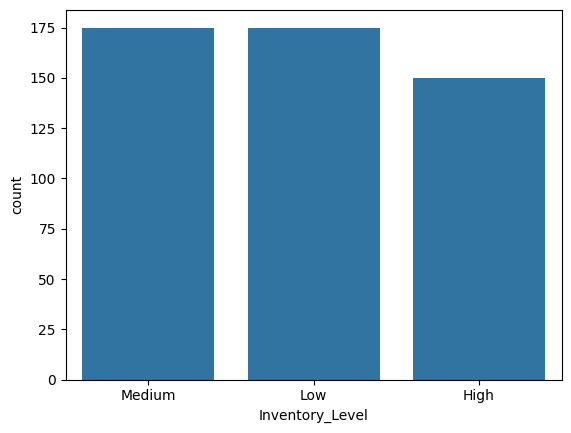

In [46]:
sns.countplot(x = 'Inventory_Level', data = df)

<Axes: xlabel='SupplyChain_Efficiency_Label', ylabel='count'>

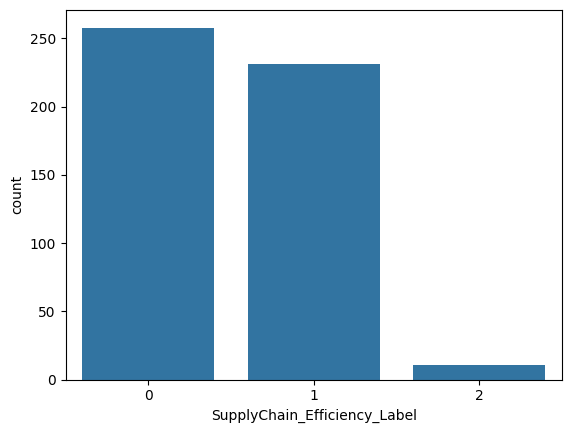

In [47]:
sns.countplot(x = 'SupplyChain_Efficiency_Label', data = df)

<Axes: xlabel='Inventory_Level', ylabel='count'>

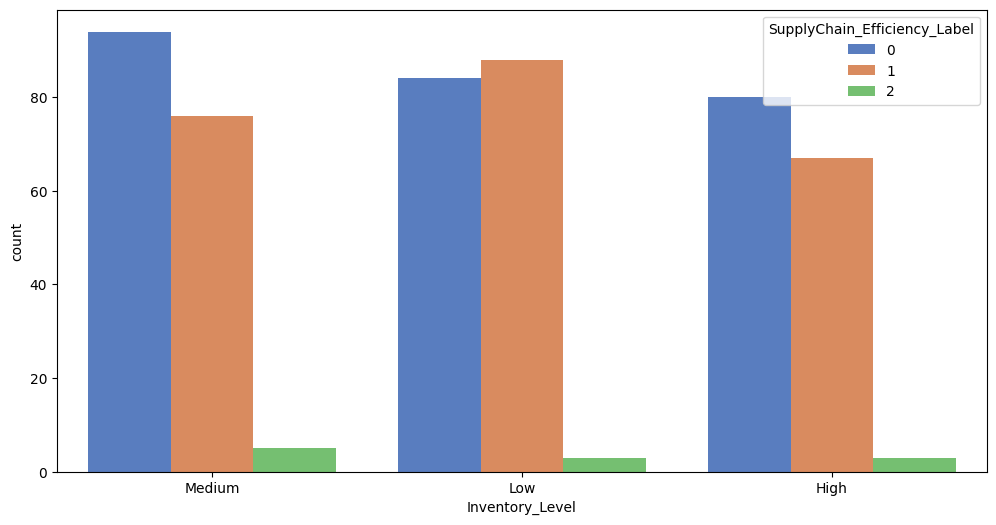

In [48]:
plt.figure(figsize=(12,6))
sns.countplot(x = 'Inventory_Level', data = df, hue='SupplyChain_Efficiency_Label', palette='muted')

<Axes: xlabel='SupplyChain_Efficiency_Label', ylabel='Logistics_Cost'>

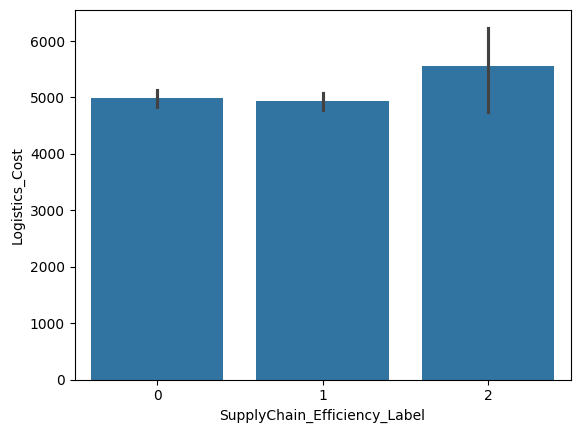

In [57]:
sns.barplot(x='SupplyChain_Efficiency_Label', y='Logistics_Cost', data=df)

<Axes: xlabel='Delivery_Efficiency', ylabel='Count'>

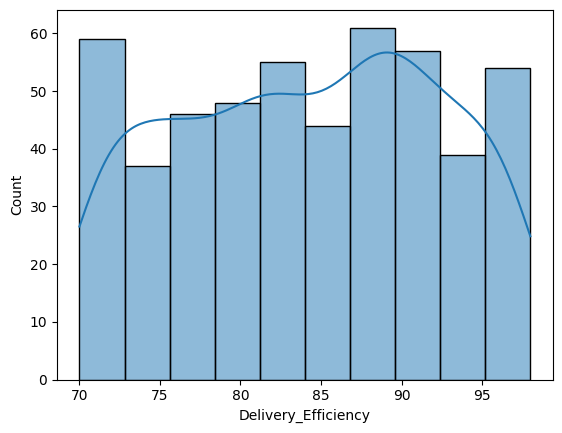

In [49]:
sns.histplot(df['Delivery_Efficiency'], kde=True, bins=10)

<Axes: xlabel='Condition_Score', ylabel='Count'>

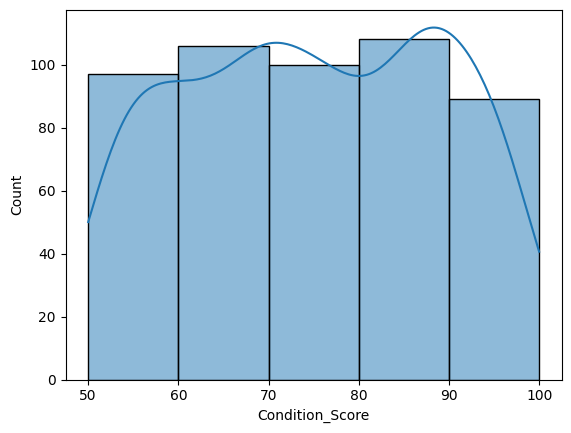

In [50]:
sns.histplot(df['Condition_Score'], kde=True, bins=5)

In [51]:
numeric_df.skew()

Temperature                    -0.007892
Vibration                       0.057420
Condition_Score                -0.045768
Resource_Utilization           -0.072809
Delivery_Efficiency            -0.078586
Downtime_Hours                 -0.009588
Logistics_Cost                  0.129316
SupplyChain_Efficiency_Label    0.391484
dtype: float64

<Axes: xlabel='Inventory_Level', ylabel='Logistics_Cost'>

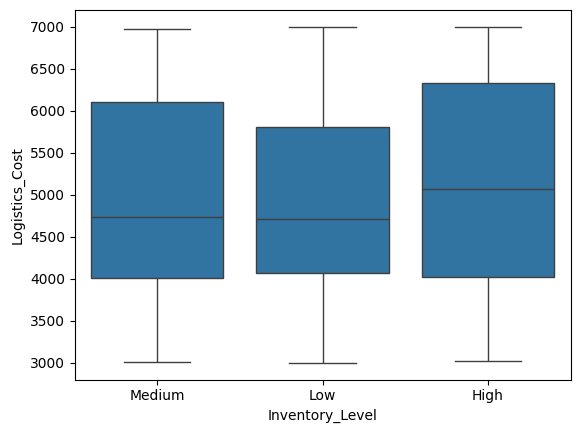

In [62]:
sns.boxplot(x='Inventory_Level', y='Logistics_Cost', data=df)

<Axes: >

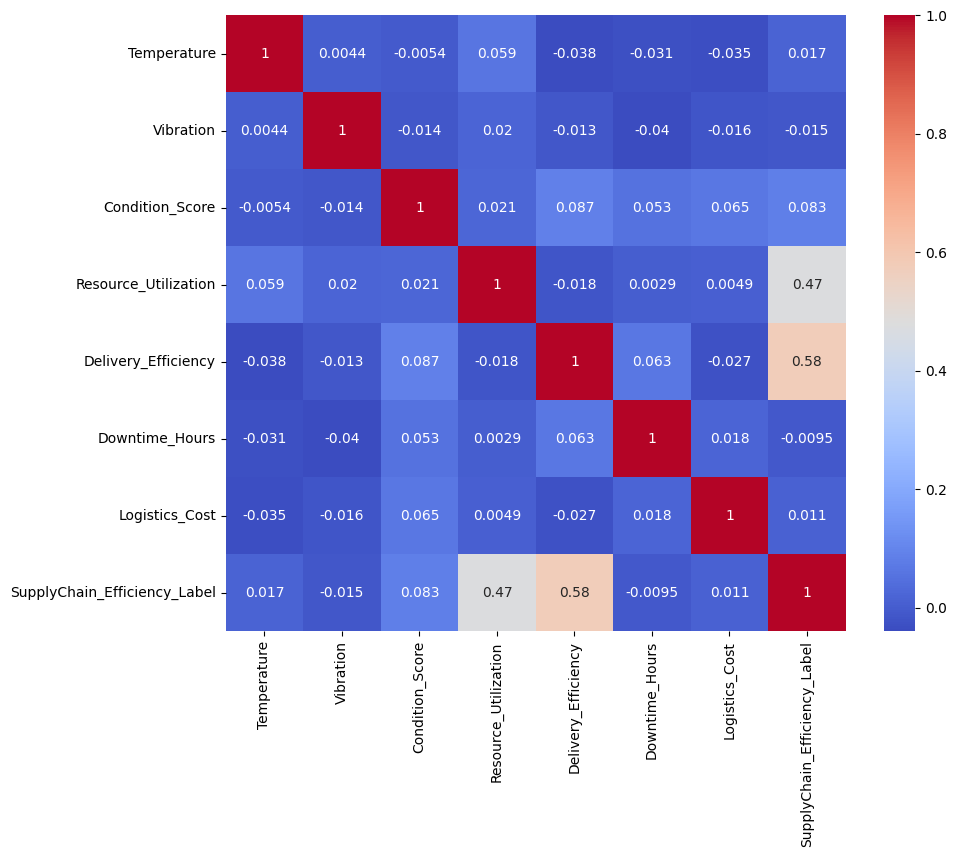

In [52]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')